In [1]:
# !pip install --user scipy==1.14.1 numpy==1.26.4 --force-reinstall -q
# !pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124 -q
# !pip install timm scikit-learn matplotlib tqdm -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import os, sys, copy, math, time, json
from datetime import datetime
from typing import Dict, Any, Optional, Tuple, List
from itertools import cycle
from functools import partial

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
from torch.utils.data import Dataset, DataLoader, random_split
import timm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Device: {device}")

PyTorch version: 2.5.1+cu124
CUDA available: True
GPU: NVIDIA H200
Device: cuda


In [2]:
CONFIG = {
    "train_dir": "/home/jovyan/work/dataset/dataset/train",
    "val_dir": "/home/jovyan/work/dataset/dataset/val",
    "img_size": 150,
    "in_channels": 1,
    "num_classes": 3,
    "batch_size": 64,
    "num_workers": 4,
    "epochs": 150,
    "patience": 30,
    "lr": 5e-4,
    "weight_decay": 0.05,
    "warmup_epochs": 10,
    "label_smoothing": 0.1,
    "save_dir": "./checkpoints",
}


class NPYImageFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.endswith('.npy'):
                    filepath = os.path.join(class_dir, filename)
                    self.samples.append((filepath, self.class_to_idx[class_name]))
        print(f"   Found {len(self.samples)} samples in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        arr = np.load(filepath)
        if arr.ndim == 2:
            arr = arr[np.newaxis, :, :]
        elif arr.ndim == 3 and arr.shape[0] not in [1, 3]:
            arr = arr.transpose(2, 0, 1)
        if arr.max() > 1.0:
            arr = arr / 255.0
        tensor = torch.from_numpy(arr).float()
        if self.transform:
            tensor = self.transform(tensor)
        return tensor, label


class NPYTransform:
    def __init__(self, img_size, augment=False):
        self.img_size = img_size
        self.augment = augment

    def __call__(self, x):
        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False).squeeze(0)
        if self.augment:
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-2])
            k = torch.randint(0, 4, (1,)).item()
            if k > 0:
                x = torch.rot90(x, k, dims=[-2, -1])
            if torch.rand(1) > 0.5:
                noise_std = torch.rand(1).item() * 0.05
                x = x + torch.randn_like(x) * noise_std
                x = torch.clamp(x, 0, 1)
            if torch.rand(1) > 0.5:
                brightness_factor = 0.8 + torch.rand(1).item() * 0.4
                x = torch.clamp(x * brightness_factor, 0, 1)
            if torch.rand(1) > 0.5:
                contrast_factor = 0.8 + torch.rand(1).item() * 0.4
                mean = x.mean()
                x = torch.clamp((x - mean) * contrast_factor + mean, 0, 1)
            if torch.rand(1) > 0.7:
                crop_ratio = 0.8 + torch.rand(1).item() * 0.15
                crop_size = int(self.img_size * crop_ratio)
                start = (self.img_size - crop_size) // 2
                x = x[:, start:start+crop_size, start:start+crop_size]
                x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                                  mode='bilinear', align_corners=False).squeeze(0)
        x = (x - 0.5) / 0.5
        return x


def get_dataloaders(config, test_split=0.15):
    train_transform = NPYTransform(config["img_size"], augment=True)
    val_transform = NPYTransform(config["img_size"], augment=False)
    train_dataset = NPYImageFolder(config["train_dir"], train_transform)
    val_full_dataset = NPYImageFolder(config["val_dir"], val_transform)
    total_val = len(val_full_dataset)
    test_size = int(total_val * test_split)
    val_size = total_val - test_size
    val_dataset, test_dataset = random_split(
        val_full_dataset, [val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"],
                              shuffle=True, num_workers=config["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"],
                            shuffle=False, num_workers=config["num_workers"], pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config["batch_size"],
                             shuffle=False, num_workers=config["num_workers"], pin_memory=True)
    return train_loader, val_loader, test_loader, train_dataset.classes


print("Loading NPY dataset...")
train_loader, val_loader, test_loader, classes = get_dataloaders(CONFIG)
print(f"\nData loaded:")
print(f"   Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}")
print(f"   Classes: {classes}")
sample_batch, _ = next(iter(train_loader))
print(f"   Batch shape: {sample_batch.shape}")

Loading NPY dataset...
   Found 30000 samples in /home/jovyan/work/dataset/dataset/train
   Found 7500 samples in /home/jovyan/work/dataset/dataset/val

Data loaded:
   Train: 30000, Val: 6375, Test: 1125
   Classes: ['no', 'sphere', 'vort']
   Batch shape: torch.Size([64, 1, 150, 150])


In [3]:
class SpectralConv2d(nn.Module):
    """2D Fourier layer: FFT -> learned complex weights -> IFFT.
    Adapted from the 3D SpectralConv3d in ufno/ufno.py to operate on 2D spatial dims.
    Covers all 4 quadrants of the 2D frequency domain (low/high freq in each axis).
    """
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(self.scale * torch.rand(
            in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(
            in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        B, C, H, W = x.shape
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(B, self.out_channels, H, W // 2 + 1,
                             dtype=torch.cfloat, device=x.device)

        m1 = min(self.modes1, H)
        m2 = min(self.modes2, W // 2 + 1)

        out_ft[:, :, :m1, :m2] = self.compl_mul2d(
            x_ft[:, :, :m1, :m2], self.weights1[:, :, :m1, :m2])
        out_ft[:, :, -m1:, :m2] = self.compl_mul2d(
            x_ft[:, :, -m1:, :m2], self.weights2[:, :, :m1, :m2])

        return torch.fft.irfft2(out_ft, s=(H, W))


class UNet2d(nn.Module):
    """2D U-Net branch for local feature extraction within UFNO layers.
    Adapted from the 3D U_net in ufno/ufno.py: 3-level encoder-decoder
    with skip connections via channel concatenation.
    """
    def __init__(self, channels, kernel_size=3, dropout_rate=0.1):
        super().__init__()
        self.conv1 = self._conv(channels, channels, kernel_size, stride=2, dropout_rate=dropout_rate)
        self.conv2 = self._conv(channels, channels, kernel_size, stride=2, dropout_rate=dropout_rate)
        self.conv2_1 = self._conv(channels, channels, kernel_size, stride=1, dropout_rate=dropout_rate)
        self.conv3 = self._conv(channels, channels, kernel_size, stride=2, dropout_rate=dropout_rate)
        self.conv3_1 = self._conv(channels, channels, kernel_size, stride=1, dropout_rate=dropout_rate)

        self.deconv2 = self._deconv(channels, channels)
        self.deconv1 = self._deconv(channels * 2, channels)
        self.deconv0 = self._deconv(channels * 2, channels)

        self.output_layer = nn.Conv2d(channels * 2, channels,
                                      kernel_size=kernel_size, stride=1,
                                      padding=(kernel_size - 1) // 2)

    def _conv(self, in_ch, out_ch, kernel_size, stride, dropout_rate):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size,
                      stride=stride, padding=(kernel_size - 1) // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate),
        )

    def _deconv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        out_conv1 = self.conv1(x)
        out_conv2 = self.conv2_1(self.conv2(out_conv1))
        out_conv3 = self.conv3_1(self.conv3(out_conv2))
        out_deconv2 = self.deconv2(out_conv3)
        out_deconv2 = F.interpolate(out_deconv2, size=out_conv2.shape[-2:], mode='bilinear', align_corners=False)
        concat2 = torch.cat((out_conv2, out_deconv2), dim=1)
        out_deconv1 = self.deconv1(concat2)
        out_deconv1 = F.interpolate(out_deconv1, size=out_conv1.shape[-2:], mode='bilinear', align_corners=False)
        concat1 = torch.cat((out_conv1, out_deconv1), dim=1)
        out_deconv0 = self.deconv0(concat1)
        out_deconv0 = F.interpolate(out_deconv0, size=x.shape[-2:], mode='bilinear', align_corners=False)
        concat0 = torch.cat((x, out_deconv0), dim=1)
        return self.output_layer(concat0)

In [4]:
class UFNOClassifier(nn.Module):
    """Pure U-shaped Fourier Neural Operator classifier.
    Mirrors ufno/ufno.py SimpleBlock3d structure exactly:
      - Lifting conv (1 -> width)
      - Layers 0-1: SpectralConv2d + 1x1 Conv (pure Fourier)
      - Layers 2-3: SpectralConv2d + 1x1 Conv + UNet2d (hybrid)
      - Projection MLP -> classifier
    No ResNet backbone.
    """
    def __init__(self, in_channels=1, num_classes=3,
                 width=64, n_modes=(16, 16), unet_kernel_size=3, unet_dropout=0.1):
        super().__init__()
        self.width = width
        modes1, modes2 = n_modes

        self.lift = nn.Sequential(
            nn.Conv2d(in_channels, width, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(width),
            nn.GELU(),
            nn.Conv2d(width, width, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(width),
            nn.GELU(),
        )

        self.spectral0 = SpectralConv2d(width, width, modes1, modes2)
        self.w0 = nn.Conv2d(width, width, 1)
        self.norm0 = nn.BatchNorm2d(width)

        self.spectral1 = SpectralConv2d(width, width, modes1, modes2)
        self.w1 = nn.Conv2d(width, width, 1)
        self.norm1 = nn.BatchNorm2d(width)

        self.spectral2 = SpectralConv2d(width, width, modes1, modes2)
        self.w2 = nn.Conv2d(width, width, 1)
        self.unet2 = UNet2d(width, unet_kernel_size, unet_dropout)
        self.norm2 = nn.BatchNorm2d(width)

        self.spectral3 = SpectralConv2d(width, width, modes1, modes2)
        self.w3 = nn.Conv2d(width, width, 1)
        self.unet3 = UNet2d(width, unet_kernel_size, unet_dropout)
        self.norm3 = nn.BatchNorm2d(width)

        self.spectral4 = SpectralConv2d(width, width, modes1, modes2)
        self.w4 = nn.Conv2d(width, width, 1)
        self.unet4 = UNet2d(width, unet_kernel_size, unet_dropout)
        self.norm4 = nn.BatchNorm2d(width)

        self.spectral5 = SpectralConv2d(width, width, modes1, modes2)
        self.w5 = nn.Conv2d(width, width, 1)
        self.unet5 = UNet2d(width, unet_kernel_size, unet_dropout)
        self.norm5 = nn.BatchNorm2d(width)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Linear(width, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.lift(x)

        x1 = self.spectral0(x)
        x2 = self.w0(x)
        x = self.norm0(F.gelu(x1 + x2))

        x1 = self.spectral1(x)
        x2 = self.w1(x)
        x = self.norm1(F.gelu(x1 + x2))

        x1 = self.spectral2(x)
        x2 = self.w2(x)
        x3 = self.unet2(x)
        x = self.norm2(F.gelu(x1 + x2 + x3))

        x1 = self.spectral3(x)
        x2 = self.w3(x)
        x3 = self.unet3(x)
        x = self.norm3(F.gelu(x1 + x2 + x3))

        x1 = self.spectral4(x)
        x2 = self.w4(x)
        x3 = self.unet4(x)
        x = self.norm4(F.gelu(x1 + x2 + x3))

        x1 = self.spectral5(x)
        x2 = self.w5(x)
        x3 = self.unet5(x)
        x = self.norm5(F.gelu(x1 + x2 + x3))

        x = self.pool(x).flatten(1)
        return self.head(x)


model = UFNOClassifier(
    in_channels=CONFIG["in_channels"],
    num_classes=CONFIG["num_classes"],
    width=64,
    n_modes=(16, 16),
    unet_kernel_size=3,
    unet_dropout=0.1,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"UFNO Classifier (pure) — {total_params:,} total params, {trainable_params:,} trainable")

UFNO Classifier (pure) — 15,004,099 total params, 15,004,099 trainable


In [5]:
class FocalCrossEntropyLoss(nn.Module):
    """Blended CrossEntropy (with label smoothing) + Focal Loss.
    CE handles the baseline well; focal loss downweights easy examples
    and focuses on hard class-boundary samples (subtle substructure differences).
    """
    def __init__(self, label_smoothing=0.1, gamma=2.0, alpha=0.7):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.gamma = gamma
        self.alpha = alpha

    def focal_loss(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

    def forward(self, logits, targets):
        return self.alpha * self.ce(logits, targets) + (1 - self.alpha) * self.focal_loss(logits, targets)


criterion = FocalCrossEntropyLoss(
    label_smoothing=CONFIG["label_smoothing"], gamma=2.0, alpha=0.7
)
print("Loss: FocalCrossEntropyLoss (0.7*CE_smooth + 0.3*Focal)")

Loss: FocalCrossEntropyLoss (0.7*CE_smooth + 0.3*Focal)


In [6]:
def plot_roc_curve(all_labels, all_probs, class_names, save_path="roc_curve.png"):
    all_labels_bin = label_binarize(all_labels, classes=range(len(class_names)))
    all_probs = np.array(all_probs)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(class_names)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.figure(figsize=(10, 8))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'micro-average (AUC = {roc_auc["micro"]:.4f})',
             color='deeppink', linestyle=':', linewidth=4)
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'macro-average (AUC = {roc_auc["macro"]:.4f})',
             color='navy', linestyle=':', linewidth=4)
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    for i, color in zip(range(len(class_names)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('UFNO-Enhanced ResNet-18 — ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right"); plt.grid(alpha=0.3)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"ROC curve saved to {save_path}")
    return roc_auc


def plot_training_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = [h['epoch'] for h in history]

    axes[0].plot(epochs, [h['train_loss'] for h in history], label='Train')
    axes[0].plot(epochs, [h['val_loss'] for h in history], label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [h['train_acc'] for h in history], label='Train')
    axes[1].plot(epochs, [h['val_acc'] for h in history], label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, [h['val_roc_auc'] for h in history], label='Val ROC-AUC',
                 color='green')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('ROC-AUC')
    axes[2].set_title('ROC-AUC'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["save_dir"], f"history_{title.replace(' ', '_')}.png"),
                dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_on_test(model, test_loader, device, class_names, model_name="model"):
    model.eval()
    all_probs, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * correct / total
    test_auc = roc_auc_score(np.array(all_labels), np.array(all_probs),
                             multi_class='ovr', average='macro')
    print(f"\n{model_name} — Test Results:")
    print(f"   Accuracy: {test_acc:.2f}%")
    print(f"   ROC-AUC (macro): {test_auc:.4f}")
    return test_acc, test_auc, all_probs, all_labels

In [7]:
def train_model(model, train_loader, val_loader, config, device, class_names,
                criterion, model_name="model"):
    num_epochs = config["epochs"]
    patience = config.get("patience", 30)
    save_dir = config["save_dir"]
    os.makedirs(save_dir, exist_ok=True)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=config.get("lr", 5e-4),
                                  weight_decay=config.get("weight_decay", 0.05))
    warmup_epochs = config.get("warmup_epochs", 10)
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, total_iters=warmup_epochs)
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs])

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"   Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"   Epochs: {num_epochs}, Patience: {patience}")
    print(f"   LR: {config.get('lr', 5e-4)}, WD: {config.get('weight_decay', 0.05)}")
    print(f"   Loss: {criterion.__class__.__name__}")
    print(f"{'='*60}\n")

    model.to(device)
    best_roc_auc = 0.0
    best_val_acc = 0.0
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_probs, best_labels = [], []
    history = []

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}',
                              'acc': f'{100*train_correct/train_total:.1f}%'})
        scheduler.step()

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_probs, all_labels_list = [], []
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
                all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        train_loss /= train_total
        train_acc = 100 * train_correct / train_total
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        try:
            val_roc_auc = roc_auc_score(np.array(all_labels_list), np.array(all_probs),
                                        multi_class='ovr', average='macro')
        except ValueError:
            val_roc_auc = 0.0

        current_lr = scheduler.get_last_lr()[0]
        history.append({'epoch': epoch+1, 'train_loss': train_loss,
                        'train_acc': train_acc, 'val_loss': val_loss,
                        'val_acc': val_acc, 'val_roc_auc': val_roc_auc,
                        'lr': current_lr})

        improved = val_roc_auc > best_roc_auc
        if improved:
            best_roc_auc = val_roc_auc
            best_val_acc = val_acc
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            best_probs, best_labels = all_probs, all_labels_list
            torch.save({
                'model_state_dict': model.state_dict(),
                'val_roc_auc': best_roc_auc, 'val_acc': best_val_acc,
                'epoch': epoch+1, 'history': history,
            }, os.path.join(save_dir, f"best_{model_name}.pth"))
            status = "NEW BEST"
        else:
            epochs_no_improve += 1
            status = f"No improve ({epochs_no_improve}/{patience})"

        print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.6f} | {status}")
        print(f"  Train: loss={train_loss:.4f}, acc={train_acc:.2f}%")
        print(f"  Val:   loss={val_loss:.4f}, acc={val_acc:.2f}%, ROC-AUC={val_roc_auc:.4f}")
        print(f"  Best:  ROC-AUC={best_roc_auc:.4f}, acc={best_val_acc:.2f}%")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\n{'='*60}")
    print(f"Training Complete: {model_name}")
    print(f"   Best ROC AUC: {best_roc_auc:.4f}")
    print(f"   Best Val Accuracy: {best_val_acc:.2f}%")
    print(f"{'='*60}\n")

    model.load_state_dict(best_model_wts)
    if best_probs and best_labels:
        plot_roc_curve(best_labels, best_probs, class_names,
                       os.path.join(save_dir, f"roc_{model_name}.png"))

    return model, history, best_probs, best_labels


Training: UFNO_Classifier
   Params: 15,004,099
   Epochs: 150, Patience: 30
   LR: 0.0005, WD: 0.05
   Loss: FocalCrossEntropyLoss



Epoch 1/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/150 | LR: 0.000054 | NEW BEST
  Train: loss=0.9183, acc=33.84%
  Val:   loss=0.9177, acc=34.73%, ROC-AUC=0.5138
  Best:  ROC-AUC=0.5138, acc=34.73%


Epoch 2/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 149/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 149/150 | LR: 0.000001 | No improve (8/30)
  Train: loss=0.2613, acc=96.56%
  Val:   loss=0.2407, acc=98.21%, ROC-AUC=0.9972
  Best:  ROC-AUC=0.9974, acc=98.02%


Epoch 150/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 150/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 150/150 | LR: 0.000001 | No improve (9/30)
  Train: loss=0.2628, acc=96.48%
  Val:   loss=0.2409, acc=98.18%, ROC-AUC=0.9972
  Best:  ROC-AUC=0.9974, acc=98.02%

Training Complete: UFNO_Classifier
   Best ROC AUC: 0.9974
   Best Val Accuracy: 98.02%



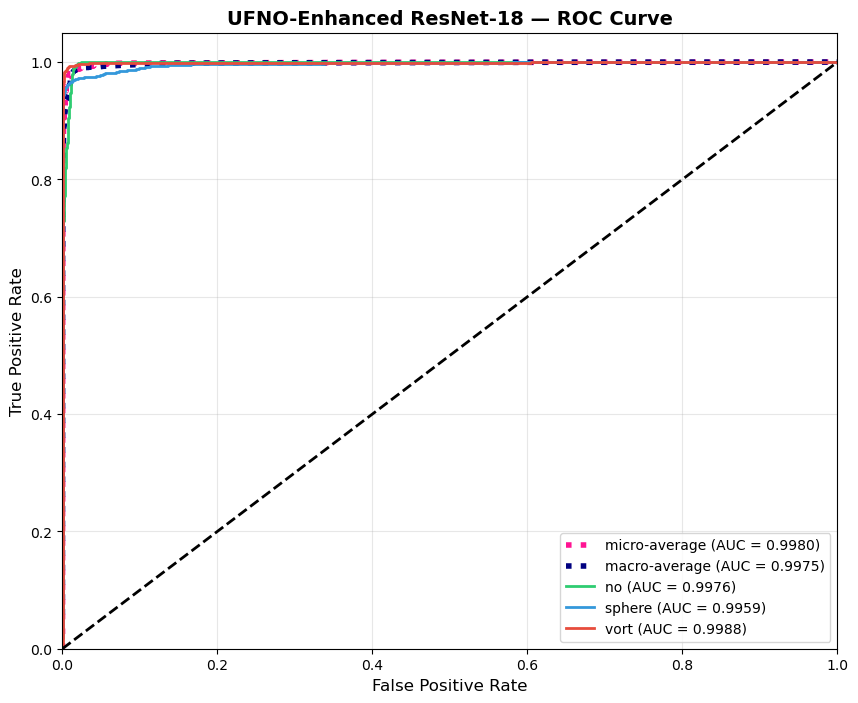

ROC curve saved to ./checkpoints/roc_UFNO_Classifier.png


In [8]:
model, history, best_probs, best_labels = train_model(
    model, train_loader, val_loader, CONFIG, device, classes,
    criterion=criterion,
    model_name="UFNO_Classifier"
)

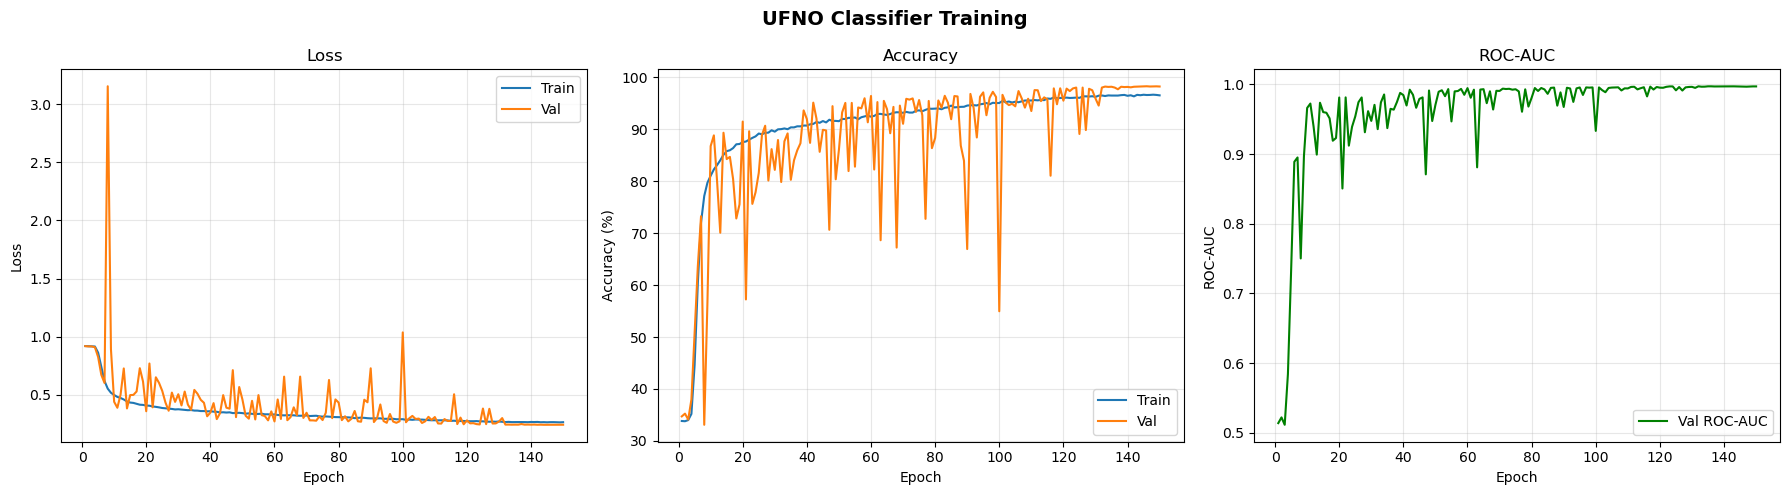

In [9]:
plot_training_history(history, title="UFNO Classifier Training")

Testing UFNO Classifier:   0%|          | 0/18 [00:00<?, ?it/s]


UFNO Classifier — Test Results:
   Accuracy: 98.31%
   ROC-AUC (macro): 0.9977


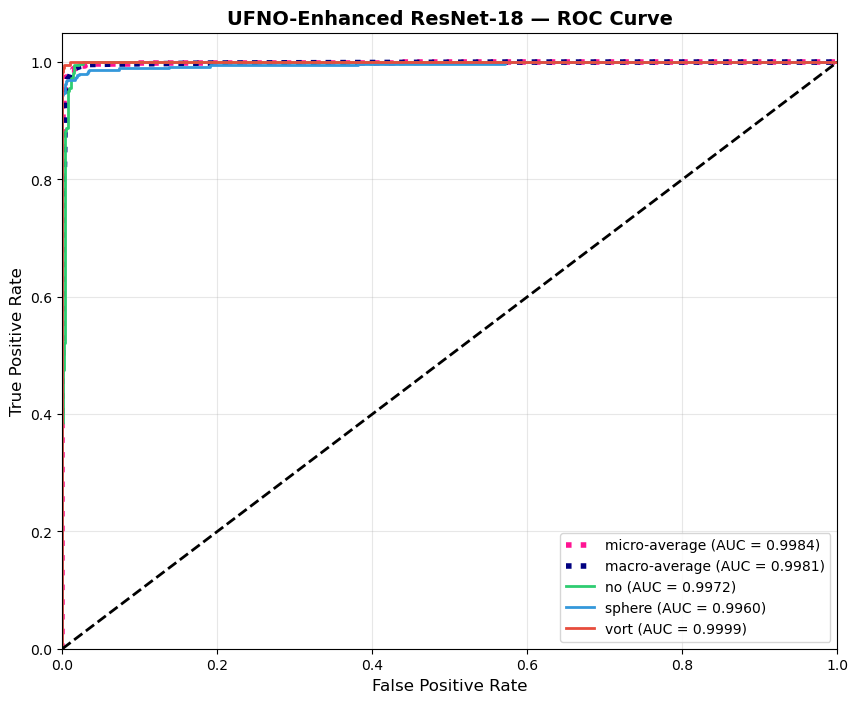

ROC curve saved to ./checkpoints/roc_test_UFNO_Classifier.png


{0: 0.9972389612446633,
 1: 0.9960372085262587,
 2: 0.9999280042045544,
 'micro': 0.9983514074074076,
 'macro': 0.998102185159755}

In [10]:
test_acc, test_auc, test_probs, test_labels = evaluate_on_test(
    model, test_loader, device, classes, "UFNO Classifier"
)

plot_roc_curve(test_labels, test_probs, classes,
               os.path.join(CONFIG["save_dir"], "roc_test_UFNO_Classifier.png"))

In [11]:
print("=" * 60)
print("RESULTS COMPARISON")
print("=" * 60)
print(f"{'Model':<30} {'ROC-AUC (macro)':>15} {'Accuracy':>10}")
print("-" * 60)
print(f"{'FNO Classifier':<30} {'0.9717':>15} {'88.31%':>10}")
print(f"{'FNO-Enhanced ResNet':<30} {'0.9888':>15} {'93.54%':>10}")
print(f"{'UFNO-Enhanced ResNet':<30} {'0.9942':>15} {'96.44%':>10}")
print(f"{'UFNO Classifier (ours)':<30} {test_auc:>15.4f} {test_acc:>9.2f}%")
print("-" * 60)
print(f"{'Common Test I Baseline':<30} {'0.9882':>15} {'93.71%':>10}")
print("=" * 60)

RESULTS COMPARISON
Model                          ROC-AUC (macro)   Accuracy
------------------------------------------------------------
FNO Classifier                          0.9717     88.31%
FNO-Enhanced ResNet                     0.9888     93.54%
UFNO-Enhanced ResNet                    0.9942     96.44%
UFNO Classifier (ours)                  0.9977     98.31%
------------------------------------------------------------
Common Test I Baseline                  0.9882     93.71%
